In [174]:
import pandas as pd
import os
import collections
from collections import Counter, defaultdict
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import json
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_score, recall_score, f1_score


print("All imports successful!")
print(f"TF version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")


All imports successful!
TF version: 2.16.1
Pandas version: 3.0.3


In [181]:
IMG_SIZE = 64

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))  # notebook directory

MODEL_PATH    = os.path.join(BASE_DIR, 'models', 'smiling_cnn_model.keras')
FAIRFACE_DIR  = os.path.join(BASE_DIR, 'data', 'fairface-img-margin125-trainval')
TRAIN_CSV     = os.path.join(FAIRFACE_DIR, 'train', 'fairface_label_train.csv')
VALID_CSV     = os.path.join(FAIRFACE_DIR, 'val',   'fairface_label_val.csv')

print("Model path:", MODEL_PATH)
print("FairFace dir:", FAIRFACE_DIR)


Model path: /Users/ife/Documents/Image classification model/Notebooks/models/smiling_cnn_model.keras
FairFace dir: /Users/ife/Documents/Image classification model/Notebooks/data/fairface-img-margin125-trainval


In [146]:
model = tf.keras.models.load_model(MODEL_PATH)
print('Model loaded')

Model loaded


In [148]:
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)
df = pd.concat([train_df,valid_df], ignore_index=True)

In [150]:
df['gender_bin'] = (df['gender'] == 'Male').astype(int)

def get_subgroup(row):
    g = 'female' if row['gender_bin'] == 0 else 'male'
    r = row['race'].lower().replace(' ','_')
    return f"{r}_{g}"

df['subgroup']= df.apply(get_subgroup,axis=1)
print('Subgroup Distribution')
print( df['subgroup'].value_counts())

Subgroup Distribution
subgroup
white_male                9823
white_female              8789
latino_hispanic_female    7545
latino_hispanic_male      7445
middle_eastern_male       7182
indian_male               7163
east_asian_male           6923
east_asian_female         6914
black_male                6895
black_female              6894
indian_female             6672
southeast_asian_male      6347
southeast_asian_female    5863
middle_eastern_female     3243
Name: count, dtype: int64


In [152]:
def load_images(img_path):
    full_path = os.path.join( FAIRFACE_IMG_DIR ,img_path)
    img = tf.io.read_file(full_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img 



In [154]:
print('Running inference')
BATCH_SIZE= 64
all_preds=[]
all_probs = []
for i in range (0 ,len(df),BATCH_SIZE):
    batch_files = df['file'].iloc[i:i+BATCH_SIZE].tolist()
    try:
        images = tf.stack([load_images(f) for f in batch_files])
        probs = model.predict(images,verbose=0).flatten()
        preds = (probs>0.5).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
    except Exception as e:
        all_probs.extend([None] * len(batch_files))
        all_preds.extend([None] * len(batch_files))

    if i% 5000 == 0:
        print( f' Processed {i}/{len(df)}')


df['pred'] = all_preds
df['prob'] = all_probs
df = df.dropna(subset=['pred'])
print(f"Inference complete — {len(df)} images processed")
        

Running inference
 Processed 0/97698
 Processed 40000/97698
 Processed 80000/97698
Inference complete — 97698 images processed


# Subgroup Analysis 

In [156]:
results ={}
for subgroup in df['subgroup'].unique():
    sub = df[df['subgroup']==subgroup]
    results[subgroup] = {
    'count': len(sub),
    'predicted_smiling_rate' : sub['pred'].mean(),
    'avg_confidence': sub['prob'].mean(),
    'avg_confidence_std': sub['prob'].std()}

results_df = pd.DataFrame(results).T.sort_index()
print("\nSubgroup Results:")
print(results_df.round(4))
    


Subgroup Results:
                         count  predicted_smiling_rate  avg_confidence  \
black_female            6894.0                  0.1931          0.2392   
black_male              6895.0                  0.1028          0.1619   
east_asian_female       6914.0                  0.1854          0.2284   
east_asian_male         6923.0                  0.0945          0.1490   
indian_female           6672.0                  0.1664          0.2083   
indian_male             7163.0                  0.1018          0.1586   
latino_hispanic_female  7545.0                  0.2338          0.2647   
latino_hispanic_male    7445.0                  0.1229          0.1730   
middle_eastern_female   3243.0                  0.1733          0.2155   
middle_eastern_male     7182.0                  0.0893          0.1478   
southeast_asian_female  5863.0                  0.1772          0.2162   
southeast_asian_male    6347.0                  0.1012          0.1510   
white_female       

# Visualization

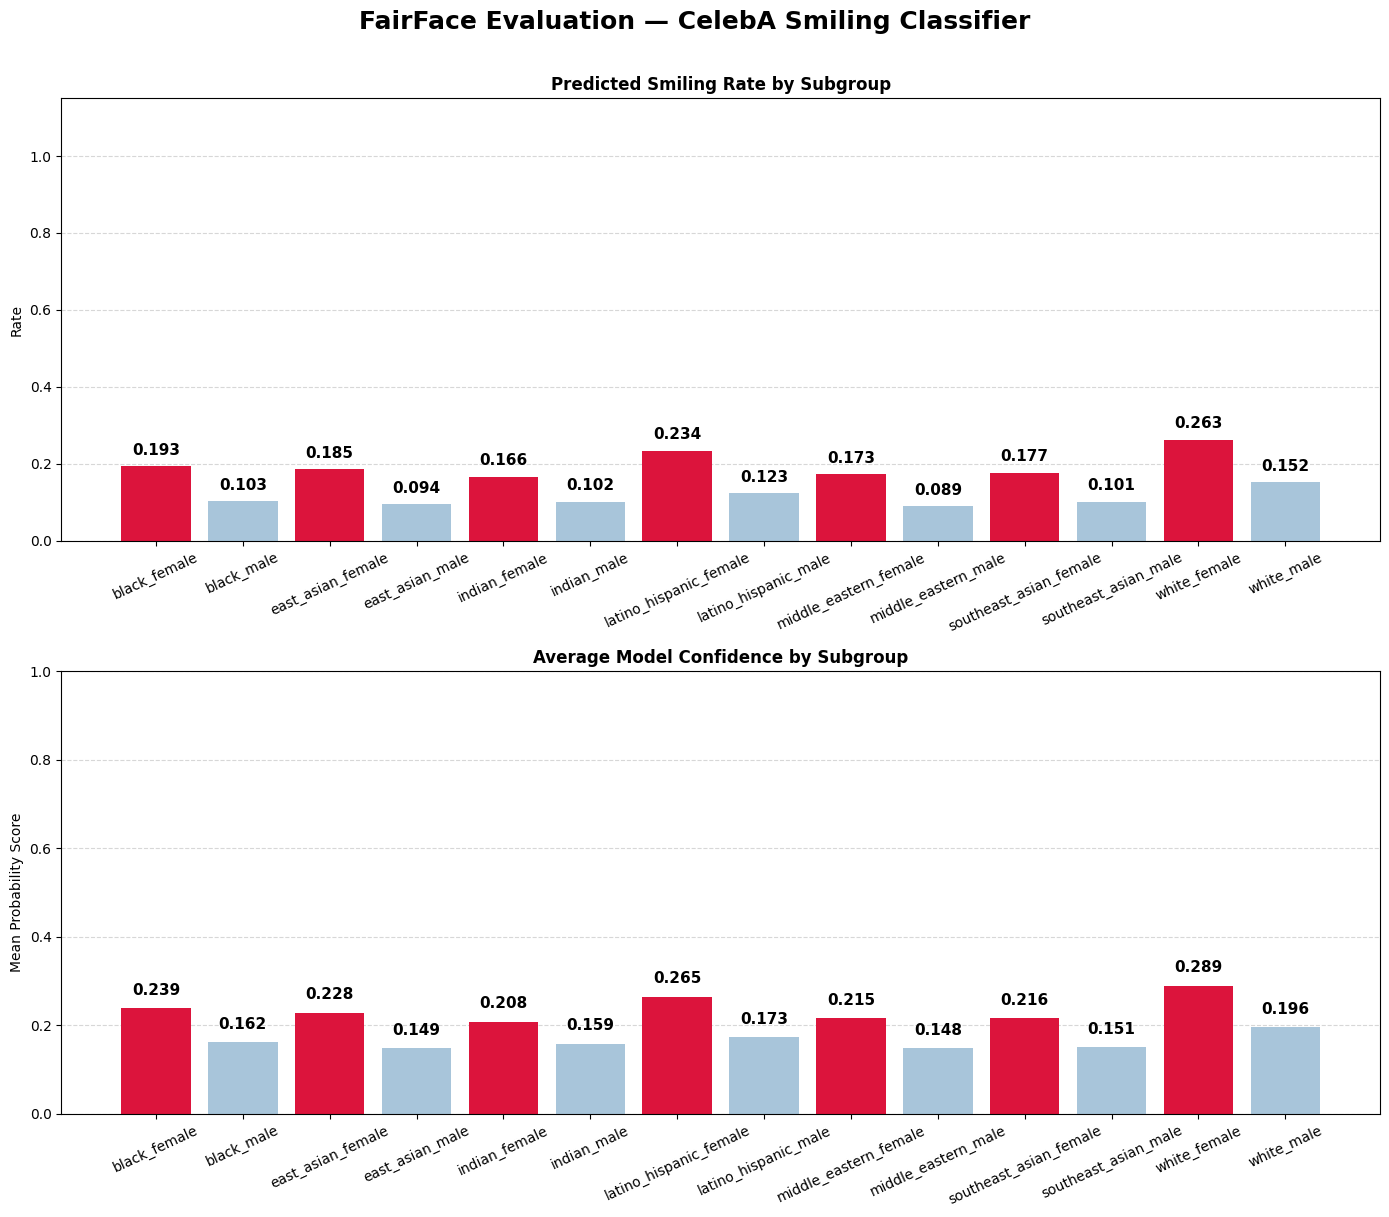

Plot saved


In [158]:
fig , axes = plt.subplots(2,1, figsize=(14,12))

colors = ['#DC143C' if 'female' in g else '#A8C5DA' for g in results_df.index]
axes[0].bar(results_df.index, results_df['predicted_smiling_rate'],color=colors)
axes[0].set_title('Predicted Smiling Rate by Subgroup', fontweight='bold')
axes[0].set_ylabel('Rate')
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis='x', rotation=25, labelsize=10)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
axes[0].set_axisbelow(True)
for i, v in enumerate(results_df['predicted_smiling_rate']):
    axes[0].text(i, v + 0.03, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

axes[1].bar(results_df.index, results_df['avg_confidence'],color=colors)
axes[1].set_title('Average Model Confidence by Subgroup', fontweight='bold')
axes[1].set_ylabel('Mean Probability Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=25, labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
axes[1].set_axisbelow(True)
for i, v in enumerate(results_df['avg_confidence']):
    axes[1].text(i, v + 0.03, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('FairFace Evaluation — CelebA Smiling Classifier', fontweight='bold',fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig('fairface_subgroup_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [160]:
results_df.to_csv('fairface_subgroup_results.csv')
print("\nResults saved to fairface_subgroup_results.csv")


Results saved to fairface_subgroup_results.csv


In [168]:
celeba_df = pd.read_csv('celeba_subgroup_metrics.csv')
print("CelebA metrics loaded:")
print(celeba_df)

CelebA metrics loaded:
             subgroup  precision    recall  f1_score
0  female_not_smiling   0.931059  0.934571  0.932812
1      female_smiling   0.931059  0.934571  0.932812
2    male_not_smiling   0.877002  0.884939  0.880952
3        male_smiling   0.877002  0.884939  0.880952


# Intersectional Bias Analysis: CelebA vs FairFace Evaluation

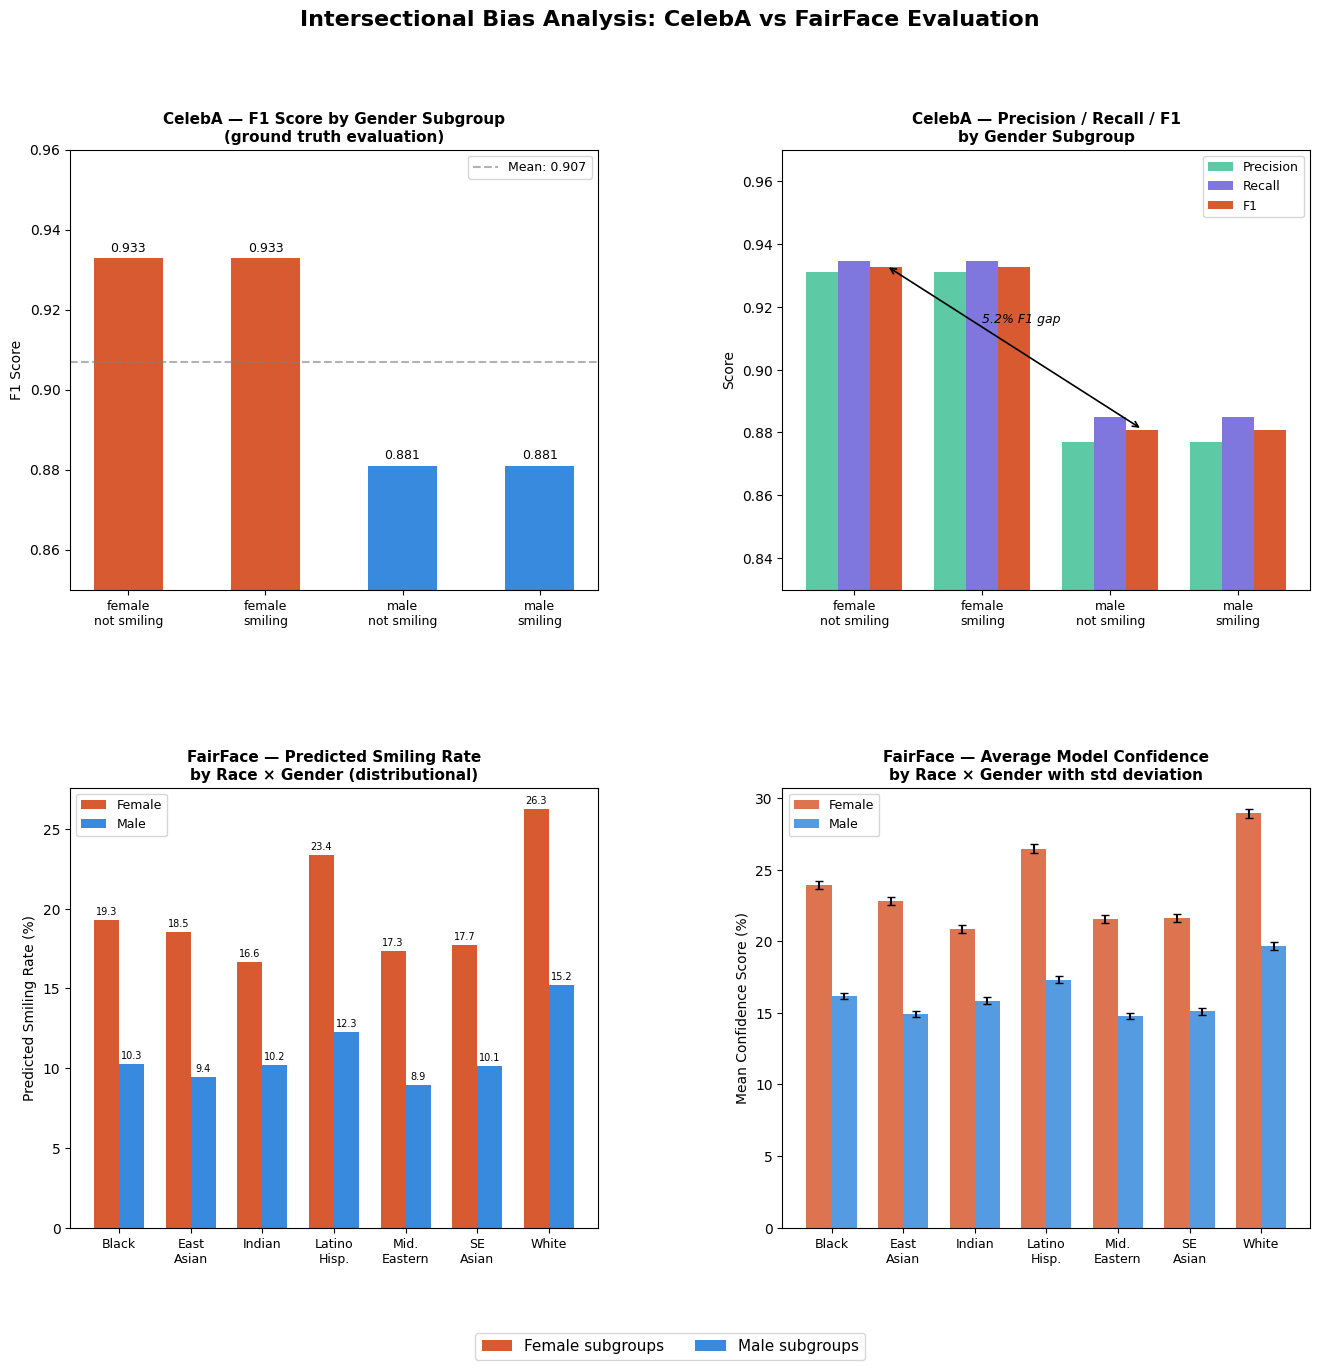

Figure saved as intersectional_bias_comparison.png


In [179]:

fig = plt.figure(figsize=(16, 14))
fig.suptitle('Intersectional Bias Analysis: CelebA vs FairFace Evaluation', 
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# PLOT 1: CelebA F1 by subgroup 
ax1 = fig.add_subplot(gs[0, 0])
colors_celeba = ['#D85A30', '#D85A30', '#378ADD', '#378ADD']
bars1 = ax1.bar(celeba_df['subgroup'], celeba_df['f1_score'], 
                color=colors_celeba, width=0.5)
ax1.set_title('CelebA — F1 Score by Gender Subgroup\n(ground truth evaluation)', 
              fontsize=11, fontweight='bold')
ax1.set_ylabel('F1 Score')
ax1.set_ylim(0.85, 0.96)
ax1.set_xticks(range(4))
ax1.set_xticklabels(['female\nnot smiling', 'female\nsmiling', 
                      'male\nnot smiling', 'male\nsmiling'], fontsize=9)
for bar, val in zip(bars1, celeba_df['f1_score']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax1.axhline(y=celeba_df['f1_score'].mean(), color='gray', 
            linestyle='--', alpha=0.6, label=f'Mean: {celeba_df["f1_score"].mean():.3f}')
ax1.legend(fontsize=9)

# PLOT 2: CelebA precision and recall
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(4)
width = 0.25
bars_p = ax2.bar(x - width, celeba_df['precision'], width, 
                  label='Precision', color='#5DCAA5')
bars_r = ax2.bar(x,          celeba_df['recall'],   width, 
                  label='Recall',    color='#7F77DD')
bars_f = ax2.bar(x + width,  celeba_df['f1_score'], width, 
                  label='F1',        color='#D85A30')
ax2.set_title('CelebA — Precision / Recall / F1\nby Gender Subgroup', 
              fontsize=11, fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_ylim(0.83, 0.97)
ax2.set_xticks(x)
ax2.set_xticklabels(['female\nnot smiling', 'female\nsmiling', 
                      'male\nnot smiling', 'male\nsmiling'], fontsize=9)
ax2.legend(fontsize=9)
# 5.2% gap annotation
ax2.annotate('', xy=(2 + width, 0.881), xytext=(0 + width, 0.933),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.2))
ax2.text(1.0, 0.915, '5.2% F1 gap', fontsize=9, color='black', style='italic')

# ─── PLOT 3: FairFace predicted smiling rate ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
races = ['Black', 'East\nAsian', 'Indian', 'Latino\nHisp.', 
         'Mid.\nEastern', 'SE\nAsian', 'White']
female_smiling = [19.31, 18.54, 16.64, 23.38, 17.33, 17.72, 26.28]
male_smiling   = [10.28,  9.45, 10.18, 12.29,  8.93, 10.12, 15.24]
x3 = np.arange(len(races))
width3 = 0.35
b1 = ax3.bar(x3 - width3/2, female_smiling, width3, 
              label='Female', color='#D85A30')
b2 = ax3.bar(x3 + width3/2, male_smiling,   width3, 
              label='Male',   color='#378ADD')
ax3.set_title('FairFace — Predicted Smiling Rate\nby Race × Gender (distributional)', 
              fontsize=11, fontweight='bold')
ax3.set_ylabel('Predicted Smiling Rate (%)')
ax3.set_xticks(x3)
ax3.set_xticklabels(races, fontsize=9)
ax3.legend(fontsize=9)
for bar, val in zip(b1, female_smiling):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', va='bottom', fontsize=7)
for bar, val in zip(b2, male_smiling):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', va='bottom', fontsize=7)

# ─── PLOT 4: FairFace confidence with std error bars ─────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
female_conf = [23.92, 22.84, 20.83, 26.47, 21.55, 21.62, 28.94]
male_conf   = [16.19, 14.90, 15.86, 17.30, 14.78, 15.10, 19.65]
female_std = results_df[results_df.index.str.endswith('_female')]['avg_confidence_std'].tolist()
male_std   = results_df[results_df.index.str.endswith('_male')]['avg_confidence_std'].tolist()

b3 = ax4.bar(x3 - width3/2, female_conf, width3, 
              yerr=female_std, capsize=3,
              label='Female', color='#D85A30', alpha=0.85)
b4 = ax4.bar(x3 + width3/2, male_conf,   width3, 
              yerr=male_std,   capsize=3,
              label='Male',   color='#378ADD', alpha=0.85)
ax4.set_title('FairFace — Average Model Confidence\nby Race × Gender with std deviation', 
              fontsize=11, fontweight='bold')
ax4.set_ylabel('Mean Confidence Score (%)')
ax4.set_xticks(x3)
ax4.set_xticklabels(races, fontsize=9)
ax4.legend(fontsize=9)

# ─── COLOR LEGEND ─────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D85A30', label='Female subgroups'),
    Patch(facecolor='#378ADD', label='Male subgroups')
]
fig.legend(handles=legend_elements, loc='lower center', 
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.01),
           frameon=True)

plt.savefig('intersectional_bias_comparison.png', dpi=150, 
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved as intersectional_bias_comparison.png")